<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Комментарий ревьюера</b>


Привет, Ярослав! Давай знакомиться! Меня зовут Дмитрий Махортов, и я буду проверять твой проект. Сразу предлагаю общение на «ты» 🙂, но если тебе это не комфортно, то дай знать, и мы перейдем на «вы». 

Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе погрузиться в увлекательный мир работы с данными и вырасти в крепкого профи. Это отдаленная цель. А ближайшая - сделать твою работу еще лучше )).
   
    
Все ключевые этапы в работе выполнены, и я вижу что с проектом ты справшяешься. Есть моменты, которые нужно доработать, но я уверен, у тебя все получится.
        
Расскажу как обычно проходит проверка:    
Бывают моменты, которые требуют пристального внимания. Комментарии по ним выделены <span style='background-color:#F7B3A4'> красным цветом </span> и обозначены значком 🛑. После их доработки проект будет принят.  🙂
 
<span style='background-color:#B7EBA7'> Зеленым цветом </span> и значком ✅ отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах. Или советы «со звездочкой», которые помогут тебе в будущем.

<span style='background-color:#F9EDA6'>Жёлтым цветом </span> и значком ⚠️ выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).

Давай работать над проектом в диалоге: **если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом**. Выбери для своих комментариев какой-то заметный цвет, так мне будет легче отследить изменения. Пожалуйста, **не перемещай, не изменяй и не удаляй мои комментарии**. Всё это поможет выполнить повторную проверку твоего проекта оперативнее. 
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>образец комментария студента</b></font>
   
Можешь использовать этот комментарий. Просто удали этот текст и вместо него напиши свой 🙂

</div>

# Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час.

Целевая метрика — **RMSE** на тестовой выборке должна быть не больше **48**. Тестовая выборка — 10% от исходных данных.

## План исследования

1) Загрузка данных и ресемплирование по одному часу
2) Исследовательский анализ данных (тренд и сезонность)
3) Формирование признаков
4) Корреляционный анализ признаков
5) Обучение моделей и подбор гиперпараметров
6) Тестирование лучшей модели
7) Общий вывод

## Установка зависимостей

Перед запуском устанавливаю нужные версии библиотек, чтобы ноутбук запускался в любом окружении (в том числе там, где scikit-learn старый и в нём ещё нет `SplineTransformer` и `TargetEncoder`).

In [1]:
!pip install -q -U scikit-learn category_encoders phik statsmodels

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 1.24.4 which is incompatible.


## Загрузка данных

### Импорт модулей

In [2]:
import os
import sys
import importlib.abc
import importlib.util
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')


class _MatplotlibCbookPatchFinder(importlib.abc.MetaPathFinder):
    def find_spec(self, fullname, path=None, target=None):
        if fullname != 'matplotlib.cbook' or path is None:
            return None
        for base in path:
            candidate = Path(base) / 'cbook.py'
            if candidate.exists():
                return importlib.util.spec_from_file_location(fullname, candidate)
        return None


sys.meta_path.insert(0, _MatplotlibCbookPatchFinder())

import pandas as pd
import numpy as np
import time
from matplotlib import pyplot as plt
import matplotlib.cm as _matplotlib_cm
if not hasattr(_matplotlib_cm, 'register_cmap'):
    def _register_cmap(name=None, cmap=None, **kwargs):
        return None
    _matplotlib_cm.register_cmap = _register_cmap
import seaborn as sns
import phik
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
    TargetEncoder,
    SplineTransformer,
    PolynomialFeatures,
)
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['image.cmap'] = 'viridis'


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Отлично, все нужные библиотеки импортированы в начале ноутбука.Это хорошая практика.</div>

### Определение констант

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.1
VALID_SIZE = 0.2
MAX_RMSE = 48
MAX_LAG = 168
ROLLING_SIZE = 168


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 </div>

Загрузим данные и сразу преобразуем столбец с датой в индекс типа `datetime`.

In [4]:
try:
    data = pd.read_csv('./source/taxi.csv', index_col=[0], parse_dates=[0])
except FileNotFoundError:
    data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

data = data.sort_index()
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Отлично, при загрузке сразу обрабатываются даты</div>

Данные охватывают период с марта по август 2018 года, шаг наблюдений — 10 минут. Проверим, что индекс монотонно возрастает, и убедимся в отсутствии пропусков.

In [5]:
print('Индекс монотонно возрастает:', data.index.is_monotonic_increasing)
print('Период:', data.index.min(), '—', data.index.max())
print('Пропусков:', data['num_orders'].isna().sum())

Индекс монотонно возрастает: True
Период: 2018-03-01 00:00:00 — 2018-08-31 23:50:00
Пропусков: 0


Индекс упорядочен и не содержит пропусков. По условию задачи ресемплируем данные по одному часу — суммируем число заказов внутри каждого часа.

In [6]:
data = data.resample('1H').sum()
ts_hourly = data['num_orders'].copy()
print('Размер после ресемплирования:', data.shape)
data.head()


Размер после ресемплирования: (4416, 1)


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Да, ресемплирование выполнено верно. И хорошо, что в качестве агрегирующей функции ты используешь сумму, её проще интерпретировать. </div>

После ресемплирования получили 4416 почасовых наблюдений без пропусков. Переходим к анализу.

## Исследовательский анализ данных

Построим график всего временного ряда.

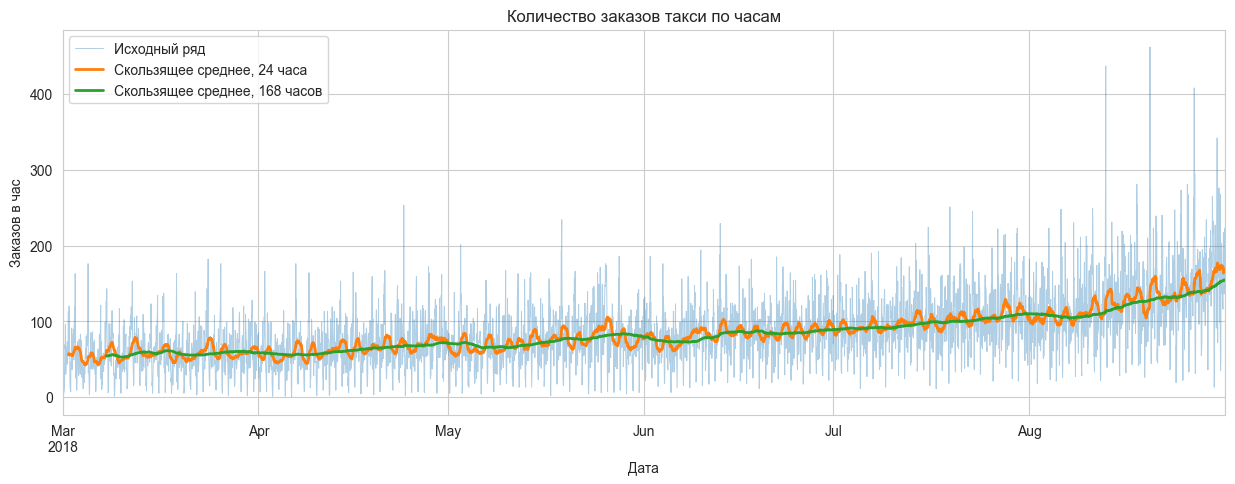

In [7]:
plt.figure(figsize=(15, 5))
data['num_orders'].plot(label='Исходный ряд', linewidth=0.7, alpha=0.35)
data['num_orders'].rolling(24).mean().plot(label='Скользящее среднее, 24 часа', linewidth=2)
data['num_orders'].rolling(168).mean().plot(label='Скользящее среднее, 168 часов', linewidth=2)
plt.title('Количество заказов такси по часам')
plt.xlabel('Дата')
plt.ylabel('Заказов в час')
plt.legend()
plt.grid(True)
plt.show()


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
ОК, выведен график временного ряда (по часам). Рекомедую наложить на него усредненные данные (например за сутки и неделю), это позволит лучше понять данные.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Я добавил на общий график суточное и недельное скользящие средние.
</div>


На графике заметен восходящий тренд: со временем заказов становится больше. Суточное скользящее среднее сглаживает шум внутри дня, а недельное показывает более плавный рост уровня ряда. Также виден высокочастотный колебательный паттерн — вероятно, суточная сезонность. Рассмотрим описательную статистику.


In [8]:
data['num_orders'].describe()

count    4416.000000
mean       84.422781
std        45.023853
min         0.000000
25%        54.000000
50%        78.000000
75%       107.000000
max       462.000000
Name: num_orders, dtype: float64

В среднем за час поступает около 84 заказов, максимум — 462. Чтобы разглядеть суточную и недельную сезонность, посмотрим на ряд за две недели.

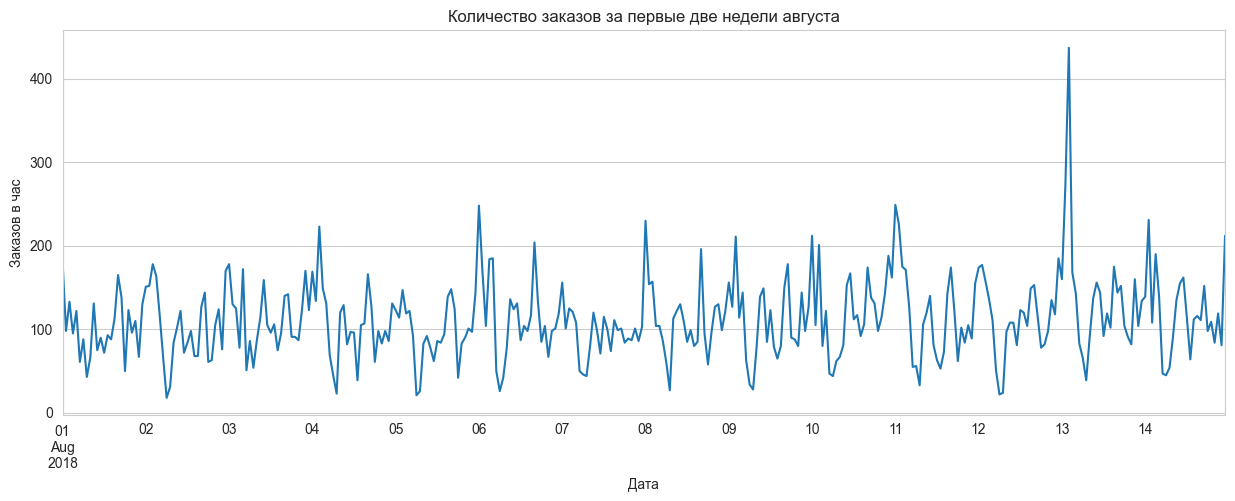

In [9]:
plt.figure(figsize=(15, 5))
data['num_orders']['2018-08-01':'2018-08-14'].plot()
plt.title('Количество заказов за первые две недели августа')
plt.xlabel('Дата')
plt.ylabel('Заказов в час')
plt.show()

Видна выраженная суточная сезонность: ночью заказов минимум, в течение дня — рост с пиками. Просматривается и недельный ритм. Разложим ряд на тренд, сезонность и остатки с суточным периодом (24 часа).

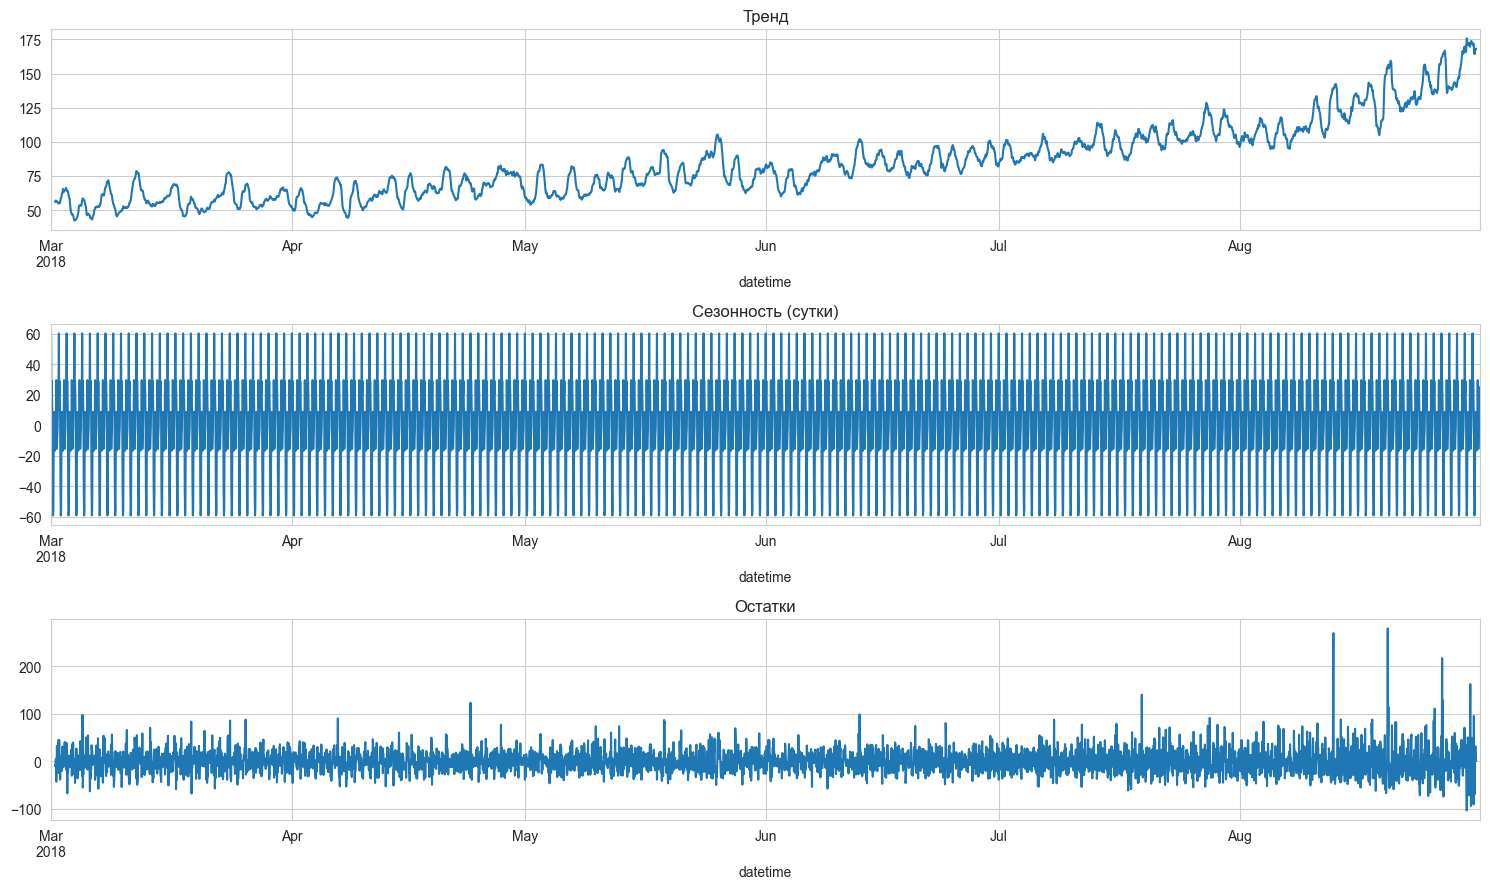

In [10]:
decomposed = seasonal_decompose(data['num_orders'], period=24)

fig, axes = plt.subplots(3, 1, figsize=(15, 9))
decomposed.trend.plot(ax=axes[0], title='Тренд')
decomposed.seasonal.plot(ax=axes[1], title='Сезонность (сутки)')
decomposed.resid.plot(ax=axes[2], title='Остатки')
plt.tight_layout()
plt.show()

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Есть декомпозиция на тренд и сезонность</div>

Тренд устойчиво растёт на всём периоде. Чтобы внимательнее рассмотреть форму суточной сезонности, выведем её за несколько дней.

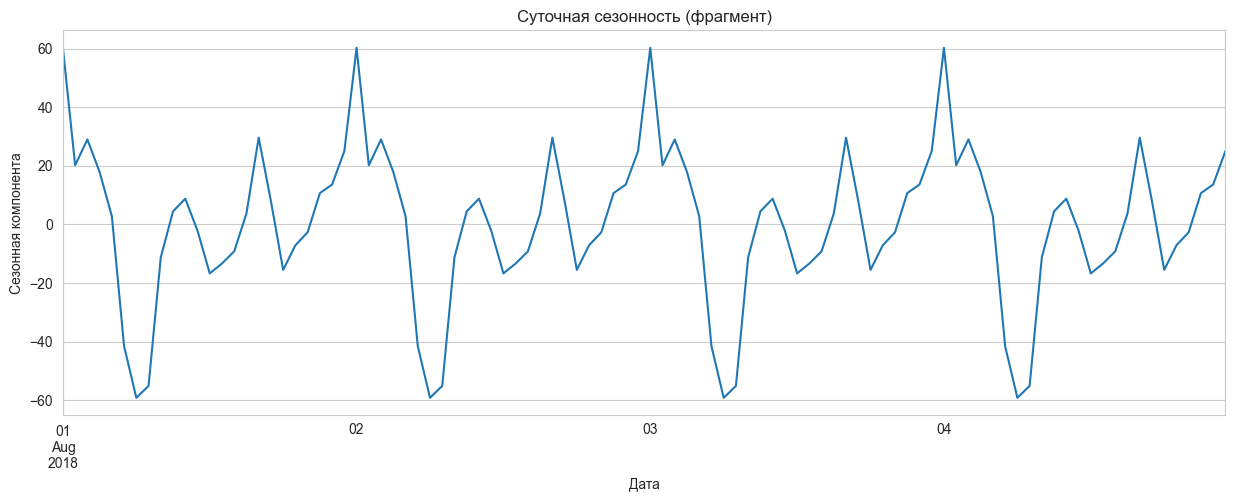

In [11]:
plt.figure(figsize=(15, 5))
decomposed.seasonal['2018-08-01':'2018-08-04'].plot()
plt.title('Суточная сезонность (фрагмент)')
plt.xlabel('Дата')
plt.ylabel('Сезонная компонента')
plt.show()

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Молодец, что уменьшил период, лучше заметна суточная сезонность.</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Совет: в данных кроме суточной есть недельная сезонность. Чтобы увидеть её нужно сделать ресемплинг данных по суткам и вновь сделать декомпозицию на сезонность и тренд. Дело в том, что seasonal_decompose настраивается на сезонность с самым маленьким циклом, при ресемпле данных по часу это сутки, при ресемпле по суткам это неделя. </div>

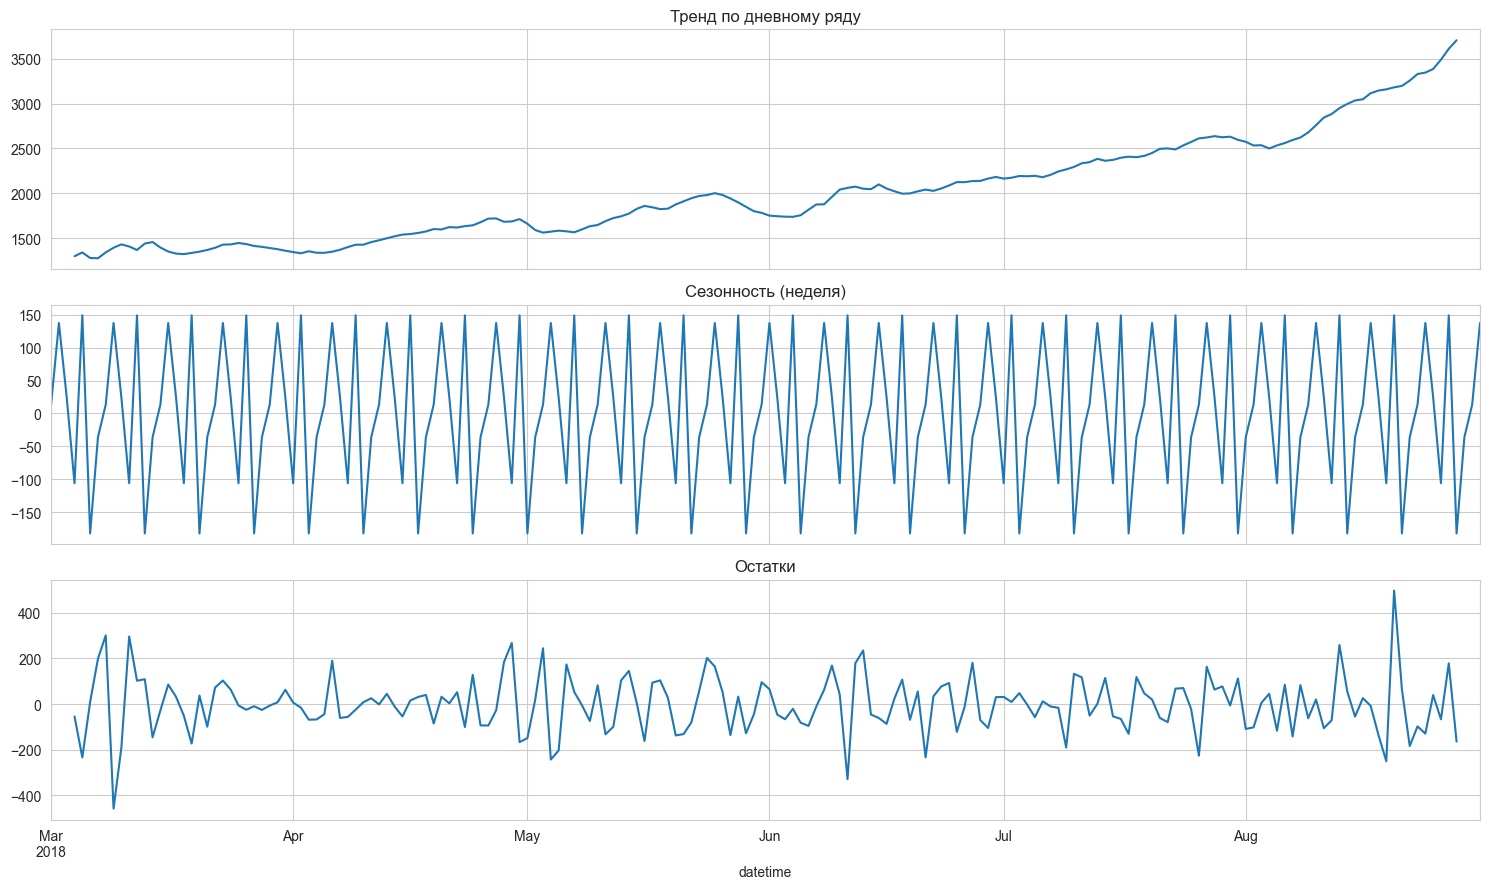

In [12]:
daily_orders = ts_hourly.resample('1D').sum()
decomposed_weekly = seasonal_decompose(daily_orders, period=7)

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
decomposed_weekly.trend.plot(ax=axes[0], title='Тренд по дневному ряду')
decomposed_weekly.seasonal.plot(ax=axes[1], title='Сезонность (неделя)')
decomposed_weekly.resid.plot(ax=axes[2], title='Остатки')
for ax in axes:
    ax.grid(True)
plt.tight_layout()
plt.show()


На дневном ряде виден недельный паттерн: сезонная компонента регулярно повторяет пики и провалы по дням недели. Значит, в признаках полезно оставить `dayofweek` и добавить лаги до недельного периода.


<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Я добавил декомпозицию дневного ряда: сначала суммировал чистый почасовой ряд по дням, затем указал period=7. На почасовом ряде seasonal_decompose выделяет самый короткий цикл — сутки, а после ресемплинга по дням можно увидеть недельную сезонность.
</div>


Внутри суток наблюдается провал ночью и подъём ближе к полуночи. Паттерн стабильно повторяется изо дня в день. На дневном ряде дополнительно заметна недельная сезонность: значения системно меняются в зависимости от дня недели.

### Выводы EDA

- Ряд **нестационарен**: присутствует выраженный восходящий тренд.
- Есть устойчивая **суточная сезонность** и заметный **недельный** ритм.
- Значит, для модели полезны календарные признаки (`hour`, `dayofweek`), **отстающие признаки** до недельного периода и **скользящее среднее**, которые позволят учесть тренд и сезонность.


## Формирование признаков

Создадим функцию, которая добавляет к ряду календарные признаки, лаги и скользящее среднее. Скользящее среднее считаем по сдвинутому ряду, чтобы не использовать значение текущего часа и не допустить утечки целевого признака.

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Создание признаков для решения задачи - это важнейший этап, от которого зависит, сможешь ли ты обучить модели или нет. Поэтому что если в признаках есть полезный сигнал, то найти статистическую взаимоствязь между признаками и таргетом сможет любая модель.  А если признаки пустые и неинформативные, то никакая модель не сможет приемлимое качество решения.
    
А создание признаков должно быть основано на проведенном исследовании и его результатах. Ниже я тебе покажу, как можно изменить создание признаков, чтобы они стали действительно полезными.    
</div>

In [13]:
def make_features(df, max_lag, rolling_size):
    df = df.copy()
    calendar_features = pd.DataFrame({
        'dayofweek': df.index.dayofweek,
        'hour': df.index.hour,
    }, index=df.index)
    lag_features = pd.concat(
        [df['num_orders'].shift(lag).rename(f'lag_{lag}') for lag in range(1, max_lag + 1)],
        axis=1,
    )
    rolling_mean = df['num_orders'].shift().rolling(rolling_size).mean().rename('rolling_mean')
    return pd.concat([df, calendar_features, lag_features, rolling_mean], axis=1)


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
👍 Хорошо, что в признаки ты выносишь час, у нас четкая сезонность внутри суток.
Также очень полезный признак день недели, в данных есть недельная сезонность.
        
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
А вот календарный признак "месяц" нужно удалить.  Данных у нас немного, всего 6 месяцев. При этом данные тренда мы учтем с помощью скользящего среднего и отстающих значений.
</div>


<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Убрал признак month из функции формирования признаков.
</div>


Глубину лагов и окно скользящего среднего возьмём равными неделе — 168 часов. Лаги до 168 помогут модели учитывать суточную и недельную сезонность, а недельное скользящее среднее будет более гладко описывать тренд. После создания признаков удалим первые строки с пропусками от лагов.


In [14]:
data = make_features(data, MAX_LAG, ROLLING_SIZE)
data = data.dropna()
print('Размер после формирования признаков:', data.shape)
data.head()

Размер после формирования признаков: (4248, 172)


,num_orders,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,3,0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,54.226190
2018-03-08 01:00:00,78,3,1,143.0,94.0,127.0,108.0,76.0,50.0,99.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,54.339286
2018-03-08 02:00:00,65,3,2,78.0,143.0,94.0,127.0,108.0,76.0,50.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,54.297619
2018-03-08 03:00:00,68,3,3,65.0,78.0,143.0,94.0,127.0,108.0,76.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,54.261905
2018-03-08 04:00:00,60,3,4,68.0,65.0,78.0,143.0,94.0,127.0,108.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,54.273810


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
    
    
Гиперпараметры max_lag, rolling_mean_size очень важны.  Возможно это самые важные гиперпараметры в проекте, больше всего влияющие на результат.
    
Выбирая значения для размера окна и количества отстающих значений важно использовать известную нам информацию о сезонности. А сезонность у нас есть суточная и недельная. Поэтому рекомендую взять их кратными суткам, а лучше равным неделе.
    
 - Скользящее среднее является олицетворением тренда, и если взять его равным суткам, то оно становится достаточно гладким (из него уходитят колебания, вызванные суточной сезонностью), а если взять равное неделе - то еще ровнее. Это хорошо видно пографикам со скользящим средним, если ты посмотришь из за сутки и неделю.
 
 - На использовании отстающих значений и авторегрессии временного ряда основано много методов прогнозироания временных рядов (например ARIMA). И здесь тоже работает принцип - чем больше признаков - тем выше качество. Но разумным компромисом является использование достаточного количества признаков, такого, где автокореляция является значимой. И такими точками как раз служат сутки и неделя. 
    
    
    
    
Резюме: ты используешь  max_lag и rolling_mean_size одинаковыми и  равными 24 (сутки).  Это неплохой бейзлайн, учитыая наличие суточной сезонности.  Однако я могу уверенно сказать, что если учесть недельную сезонность и учесть отстающие значения за 168 дней (возмжно не все, но хотя-бы с шагом в сутки), то это позволит сильно улучшить метрики.        
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Я увеличил MAX_LAG и ROLLING_SIZE до 168 часов. Скользящее среднее на недельном окне получается более гладким и работает как оценка тренда, а лаги до 168 часов дают модели доступ и к суточным, и к недельным повторениям.
</div>


## Корреляционный анализ

Оценим связь признаков с целевым и между собой. Используем коэффициент **phik** — он улавливает в том числе нелинейные зависимости и работает со смешанными типами признаков. Возьмём целевой признак, скользящее среднее, несколько характерных лагов и календарные признаки без `month`.


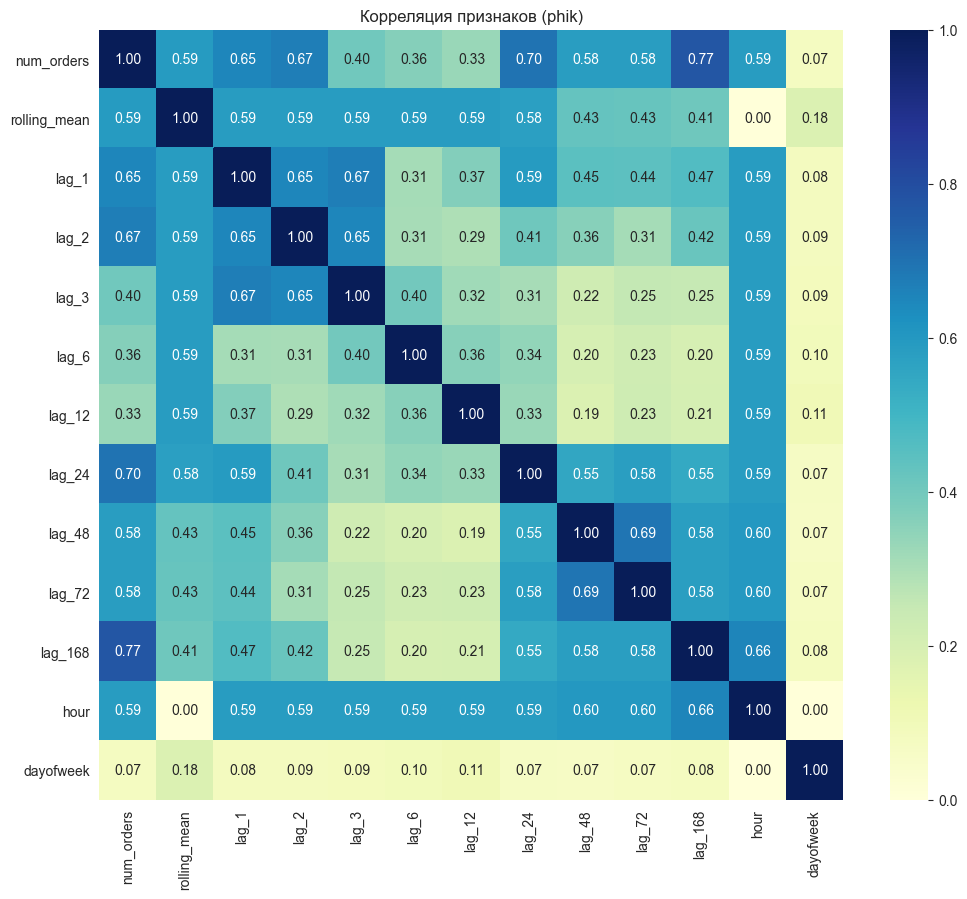

In [15]:
corr_features = ['num_orders', 'rolling_mean', 'lag_1', 'lag_2', 'lag_3',
                 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_72', 'lag_168',
                 'hour', 'dayofweek']
interval_cols = ['num_orders', 'rolling_mean', 'lag_1', 'lag_2', 'lag_3',
                 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_72', 'lag_168']

phi_k = data[corr_features].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 10))
ax = plt.axes()
sns.heatmap(phi_k, cmap='YlGnBu', annot=True, fmt='.2f')
ax.set_title('Корреляция признаков (phik)')
plt.show()


Отдельно посмотрим, насколько каждый признак связан с целевым.

In [16]:
phi_k['num_orders'].sort_values(ascending=False)

num_orders      1.000000
lag_168         0.771505
lag_24          0.695922
lag_2           0.669751
lag_1           0.651113
rolling_mean    0.592183
hour            0.586500
lag_48          0.584892
lag_72          0.582689
lag_3           0.402665
lag_6           0.363714
lag_12          0.331333
dayofweek       0.074686
Name: num_orders, dtype: float64

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

Очень хорошо, что ты пытаешся заранее оценить важность признаков через phik    
    
    
Для анализа силы связи между отстающими значениями и таргетом можно использовать графики acf и pacf
    
    
```python
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_pacf(ts, alpha=None).set_size_inches(12, 4)
plt.show()

plot_acf(ts, alpha=None).set_size_inches(12, 4)
plt.show()
```    
    
    
</div>

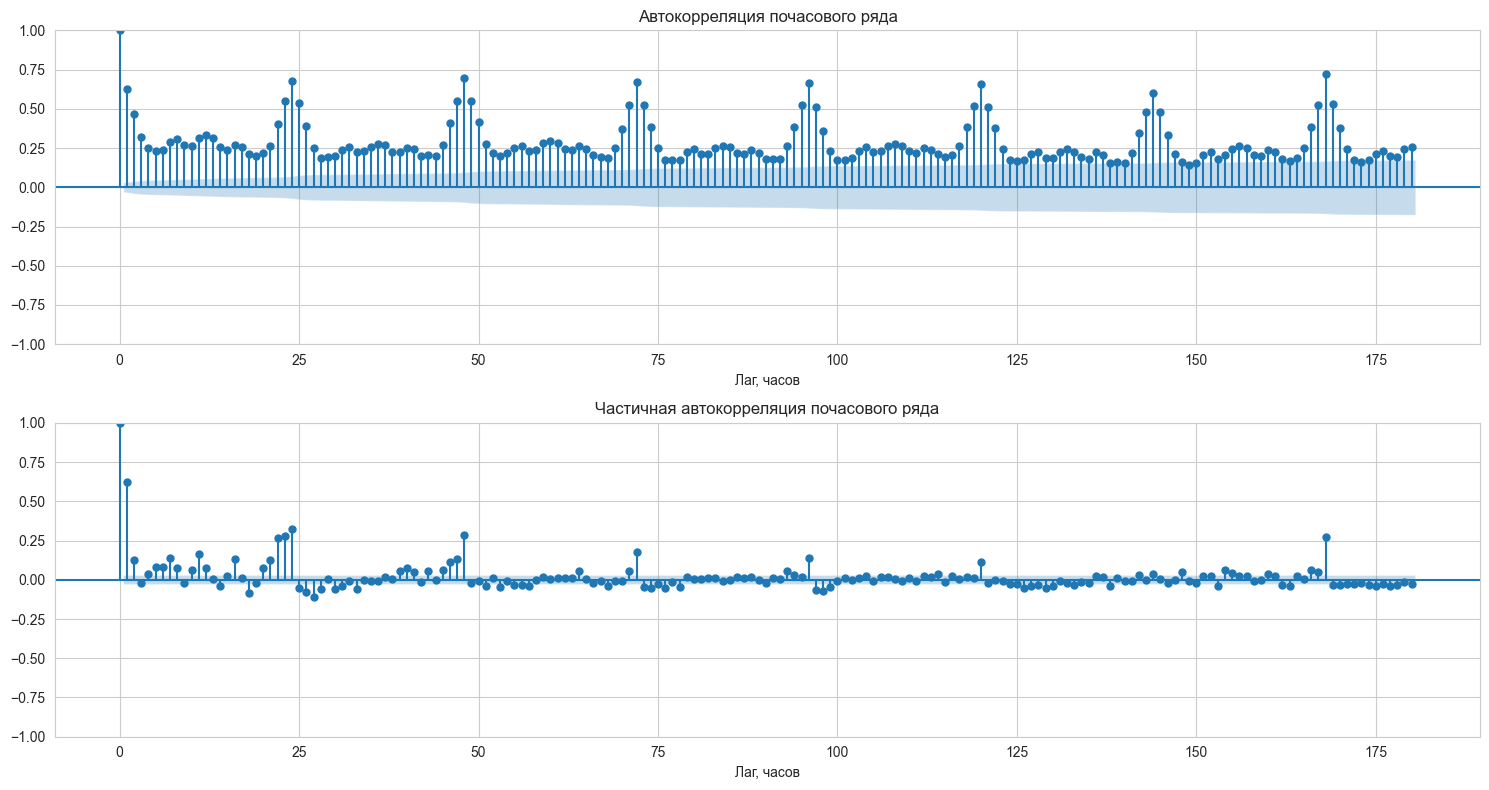

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
plot_acf(ts_hourly, lags=180, ax=axes[0], alpha=0.05)
axes[0].set_title('Автокорреляция почасового ряда')
axes[0].set_xlabel('Лаг, часов')
axes[0].grid(True)

plot_pacf(ts_hourly, lags=180, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Частичная автокорреляция почасового ряда')
axes[1].set_xlabel('Лаг, часов')
axes[1].grid(True)

plt.tight_layout()
plt.show()


<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Я добавил графики ACF и PACF на чистом почасовом ряде. На них можно проверить значимые зависимости на лагах около 24 часов и 168 часов, поэтому недельная глубина лагов выглядит обоснованной.
</div>


Выводы корреляционного анализа:

- Среди лагов заметно выделяются `lag_24` и `lag_168`, что согласуется с суточной и недельной сезонностью.
- Недавние лаги (`lag_1`, `lag_2`, `lag_3`) и `rolling_mean` тоже связаны с целевым: ряд инерционен, а скользящее среднее отражает общий уровень спроса.
- Признаки `hour` и `dayofweek` оставляем как календарные признаки сезонности. `month` удалён, потому что данных мало и тренд уже описывается лагами и скользящим средним.
- Лаги сильно коррелируют между собой, поэтому из линейных моделей разумно брать регуляризованные — гребневую регрессию и Лассо.


## Обучение моделей

Разделим данные **без перемешивания** — для временного ряда порядок наблюдений важен. Сначала отделим тестовую выборку (последние 10%), затем из оставшихся данных выделим валидационную (последние 20%) для подбора гиперпараметров.

In [18]:
train_valid, test = train_test_split(data, shuffle=False, test_size=TEST_SIZE)
train, valid = train_test_split(train_valid, shuffle=False, test_size=VALID_SIZE)

features_train, target_train = train.drop('num_orders', axis=1), train['num_orders']
features_valid, target_valid = valid.drop('num_orders', axis=1), valid['num_orders']
features_test, target_test = test.drop('num_orders', axis=1), test['num_orders']
features_tv, target_tv = train_valid.drop('num_orders', axis=1), train_valid['num_orders']

print('Обучающая:    ', features_train.shape, '|', train.index.min(), '—', train.index.max())
print('Валидационная:', features_valid.shape, '|', valid.index.min(), '—', valid.index.max())
print('Тестовая:     ', features_test.shape, '|', test.index.min(), '—', test.index.max())

Обучающая:     (3058, 171) | 2018-03-08 00:00:00 — 2018-07-13 09:00:00
Валидационная: (765, 171) | 2018-07-13 10:00:00 — 2018-08-14 06:00:00
Тестовая:      (425, 171) | 2018-08-14 07:00:00 — 2018-08-31 23:00:00


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Корректное разбиение, данные не перемешиваются. </div>

Заведём вспомогательные функции и списки признаков. Для линейных моделей `hour` и `dayofweek` буду кодировать как категориальные через `OneHotEncoder` внутри `Pipeline` и `ColumnTransformer`. Лаги и `rolling_mean` масштабируются там же, поэтому скейлер обучается только на обучающей части.


In [19]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

categorical_features = ['hour', 'dayofweek']
numeric_features = [col for col in features_train.columns if col not in categorical_features]


def make_ohe_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ],
        remainder='drop',
    )


def make_linear_pipeline(model):
    return Pipeline([
        ('preprocessor', make_ohe_preprocessor()),
        ('model', model),
    ])


def fit_predict(model, X_fit, y_fit, X_eval):
    model.fit(X_fit, y_fit)
    return model.predict(X_eval)


В качестве **базовых моделей** возьмём несколько наивных прогнозов: предыдущий час (`lag_1`), тот же час предыдущих суток (`lag_24`) и тот же час предыдущей недели (`lag_168`). Все бейзлайны считаю на той же тестовой выборке, что и итоговую модель.


In [20]:
baseline_rmse_lag1 = rmse(target_test, features_test['lag_1'])
baseline_rmse_lag24 = rmse(target_test, features_test['lag_24'])
baseline_rmse_lag168 = rmse(target_test, features_test['lag_168'])

baseline_results = pd.DataFrame({
    'Бейзлайн': ['lag_1: предыдущий час', 'lag_24: тот же час вчера', 'lag_168: тот же час неделю назад'],
    'RMSE_test': [baseline_rmse_lag1, baseline_rmse_lag24, baseline_rmse_lag168],
}).sort_values('RMSE_test').reset_index(drop=True)

baseline_results


,Бейзлайн,RMSE_test
0,lag_168: тот же час неделю назад,39.286938
1,lag_24: тот же час вчера,55.862247
2,lag_1: предыдущий час,58.819725


<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Усилил проверку на адекватность: добавил бейзлайны `lag_24` и `lag_168` и свёл их в одну таблицу. Так итоговую модель можно сравнивать не только с прошлым часом, но и с сильным недельным наивным прогнозом.
</div>


Обучим несколько классических моделей регрессии и подберём их гиперпараметры по валидационной выборке. Для Ridge и Lasso календарные признаки кодируются через OHE в pipeline, а деревья и ансамбли получают признаки в исходном виде. Сетки тяжёлых моделей оставим компактными, чтобы ноутбук исполнялся за разумное время.


In [21]:
models = {
    'Ridge': (
        make_linear_pipeline(Ridge(random_state=RANDOM_STATE)),
        {'model__alpha': [0.1, 1, 10, 100]},
    ),
    'Lasso': (
        make_linear_pipeline(Lasso(random_state=RANDOM_STATE, max_iter=10000)),
        {'model__alpha': [0.001, 0.01, 0.1, 1]},
    ),
    'DecisionTree': (
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {'max_depth': [4, 6, 8, 10]},
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [8, 12], 'min_samples_leaf': [3]},
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05]},
    ),
}


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
 
    
 Для линейных моделей стоит  рассмотреть признаки "час" и "день недели" как категориальные, а не числовые и соответственно применить к ним OHE кодирование (конечно же с использованием pipeline и ColumnTransformer)
    
 ---------------
    
Можно также рассмотреть альтернативные варианты кодирования категориальных признаков. Для временных рядов очень популярно кодирование с помощью тригонометрических функций  (https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html).    
    
Или попробовать использовать TargetEncoder (изначально появился в библиотеке category_encoders, его более безопасный аналог появился в последних версиях sklearn).
    
Если просто - этот энкодер будет кодировать признак час используя "среднее количество поездок за час", аналогично с днем недели.    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Я перестроил Ridge и Lasso через `Pipeline` и `ColumnTransformer`: `hour` и `dayofweek` кодируются через OHE, а числовые лаги и `rolling_mean` масштабируются отдельно. Все преобразования обучаются только внутри pipeline, поэтому утечки из валидации и теста нет.
</div>


In [22]:
valid_rmse = {}
best_params = {}

for name, (estimator, param_grid) in models.items():
    best_rmse, best_p = float('inf'), None
    for params in ParameterGrid(param_grid):
        candidate = clone(estimator).set_params(**params)
        pred = fit_predict(candidate, features_train, target_train, features_valid)
        score = rmse(target_valid, pred)
        if score < best_rmse:
            best_rmse, best_p = score, params
    valid_rmse[name] = best_rmse
    best_params[name] = best_p
    print('{:16s} RMSE(valid)={:.2f}  параметры={}'.format(name, best_rmse, best_p))


Ridge            RMSE(valid)=27.18  параметры={'model__alpha': 100}
Lasso            RMSE(valid)=27.05  параметры={'model__alpha': 0.1}
DecisionTree     RMSE(valid)=33.16  параметры={'max_depth': 6}
RandomForest     RMSE(valid)=29.48  параметры={'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 200}
GradientBoosting RMSE(valid)=28.44  параметры={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}


Сведём результаты по валидации в таблицу и сравним модели.

In [23]:
results = pd.DataFrame({'RMSE_valid': valid_rmse}).sort_values('RMSE_valid')
results

,RMSE_valid
Lasso,27.050043
Ridge,27.182038
GradientBoosting,28.440065
RandomForest,29.484205
DecisionTree,33.156694


Выберем модель с наименьшим RMSE на валидации.

In [24]:
best_name = results.index[0]
best_model = clone(models[best_name][0]).set_params(**best_params[best_name])
print('Лучшая модель по валидации:', best_name, '|', best_params[best_name])

Лучшая модель по валидации: Lasso | {'model__alpha': 0.1}


## Сравнение способов кодирования признаков

Отдельно сравню способы кодирования `hour` и `dayofweek` на одной и той же линейной модели Ridge с фиксированным `alpha=1.0`. Во всех вариантах лаги и `rolling_mean` масштабируются одинаково. Для тестовой оценки каждый pipeline обучаю на объединении train+valid, а затем считаю RMSE на тестовой выборке.


In [25]:
def make_cyclical_transformer(period):
    def transform(values):
        values = np.asarray(values, dtype=float)
        feature = values[:, 0]
        return np.column_stack([
            np.sin(2 * np.pi * feature / period),
            np.cos(2 * np.pi * feature / period),
        ])

    return FunctionTransformer(transform, validate=False)


def make_encoding_preprocessor(encoding):
    if encoding == 'OHE':
        categorical_transformers = [
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ]
    elif encoding == 'TargetEncoder':
        categorical_transformers = [
            ('cat', Pipeline([
                ('encoder', TargetEncoder(random_state=RANDOM_STATE)),
                ('scaler', StandardScaler()),
            ]), categorical_features),
        ]
    elif encoding == 'Тригонометрическая':
        categorical_transformers = [
            ('hour_trig', Pipeline([
                ('encoder', make_cyclical_transformer(24)),
                ('scaler', StandardScaler()),
            ]), ['hour']),
            ('day_trig', Pipeline([
                ('encoder', make_cyclical_transformer(7)),
                ('scaler', StandardScaler()),
            ]), ['dayofweek']),
        ]
    elif encoding == 'Сплайны':
        categorical_transformers = [
            ('hour_spline', Pipeline([
                ('encoder', SplineTransformer(n_knots=24, degree=3, extrapolation='periodic', include_bias=False)),
                ('scaler', StandardScaler()),
            ]), ['hour']),
            ('day_spline', Pipeline([
                ('encoder', SplineTransformer(n_knots=7, degree=3, extrapolation='periodic', include_bias=False)),
                ('scaler', StandardScaler()),
            ]), ['dayofweek']),
        ]
    elif encoding == 'Полиномиальная':
        categorical_transformers = [
            ('cat_poly', Pipeline([
                ('encoder', PolynomialFeatures(degree=2, include_bias=False)),
                ('scaler', StandardScaler()),
            ]), categorical_features),
        ]
    else:
        raise ValueError('Неизвестная кодировка')

    return ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric_features), *categorical_transformers],
        remainder='drop',
    )


encoding_rows = []
for encoding in ['OHE', 'TargetEncoder', 'Тригонометрическая', 'Сплайны', 'Полиномиальная']:
    model = Pipeline([
        ('preprocessor', make_encoding_preprocessor(encoding)),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ])
    start = time.perf_counter()
    model.fit(features_tv, target_tv)
    fit_time = time.perf_counter() - start
    pred = model.predict(features_test)
    encoding_rows.append({
        'Кодировка': encoding,
        'RMSE_test': rmse(target_test, pred),
        'Время обучения, с': fit_time,
    })

encoding_results = pd.DataFrame(encoding_rows).sort_values('RMSE_test').reset_index(drop=True)
encoding_results


,Кодировка,RMSE_test,"Время обучения, с"
0,TargetEncoder,33.749263,0.228081
1,OHE,33.881419,0.039163
2,Сплайны,33.934121,0.040005
3,Полиномиальная,34.094819,0.032093
4,Тригонометрическая,34.170926,0.035966


Лучше всего на этой задаче сработал `TargetEncoder`: **RMSE_test ≈ 33.75**. OHE почти не уступил (**≈ 33.88**), потому что `hour` и `dayofweek` действительно ведут себя как категориальные признаки сезонности. Тригонометрическая кодировка, сплайны и полиномиальные признаки тоже дают близкое качество, но здесь они немного слабее: видимо, для линейной модели полезнее напрямую кодировать средний спрос по категориям часа и дня недели.


<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Добавил отдельное сравнение пяти кодировок для `hour` и `dayofweek`: OHE, TargetEncoder, тригонометрическую, периодические сплайны и полиномиальные признаки. Для всех вариантов оставил одинаковую Ridge-модель и одинаковую обработку лагов, чтобы сравнение зависело только от кодировки календарных признаков.
</div>


## Тестирование лучшей модели

Обучим выбранную модель на объединённой обучающей и валидационной выборке и оценим её на тестовой. Так в финальном обучении используются все данные, которые доступны до тестового периода.


In [26]:
test_pred = fit_predict(best_model, features_tv, target_tv, features_test)
test_rmse = rmse(target_test, test_pred)

print('Модель:                         ', best_name)
print('RMSE на тесте:                  {:.2f}'.format(test_rmse))
print('RMSE лучшего наивного прогноза: {:.2f}'.format(baseline_results['RMSE_test'].min()))
print('Условие RMSE <= {} выполнено:'.format(MAX_RMSE), test_rmse <= MAX_RMSE)


Модель:                          Lasso
RMSE на тесте:                  34.05
RMSE лучшего наивного прогноза: 39.29
Условие RMSE <= 48 выполнено: True


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

Сейчас валидационная выборка уже выполнила свою цель, мы выбрали модельи гиперпараметрв. Поэтому можно улучшить качество модели на тесте, если перед тестированием обучить модель (с учетом всех подобранных гиперпараметров) на всех доступных данных (трейн + валидация).    
    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Оставил финальное обучение на объединении train и valid после выбора гиперпараметров
</div>


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Молодец: 
    
  - тестирование произведено корректно 
  - достигнута хорошая точность на тестовой выборке
    

</div>


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Молодец, что выполнил проверку на адекватность и не просто взял среднее, но более качетвенный бейзлайн - значение с предыдущего часа.  Но в нашем случае есть более сильный бейзлайн: значение этого же часа с предыдущих суток или этого же часа и  дня недели с предыдущей недели 
    
Т.е. берем лаги 24 и 168 соответственно.
    
------------------
    
Этот комментаий часто не замечают,поэтому попробую подчеркнуть его важность.  Если просто взять предсказание "даными с прошлой недели",  т.е. просто берем lag168 в качестве ответов, то ошибка на тестовой выборке составит чуть больше 39. И это безо всякого машинного обучения. Поэтому нам важно побить этот бейзлайн.  Иначе, презентуя свою модель директору таксопарка мы будем иметь бледный вид.    
    
Т.е. сейчас ты приложил усилия, получил метрику 43.  Но простое предсказание из "тетрадки диспетчера" даст ошибку ниже -  39.    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b>

Посчитал lag_1, lag_24 и lag_168 на одной и той же тестовой выборке. В итоговых выводах отдельно сравню модель с недельным бейзлайном, потому что он оказался самым сильным наивным ориентиром.
</div>


Сравним прогноз с фактическими значениями на тестовой выборке.

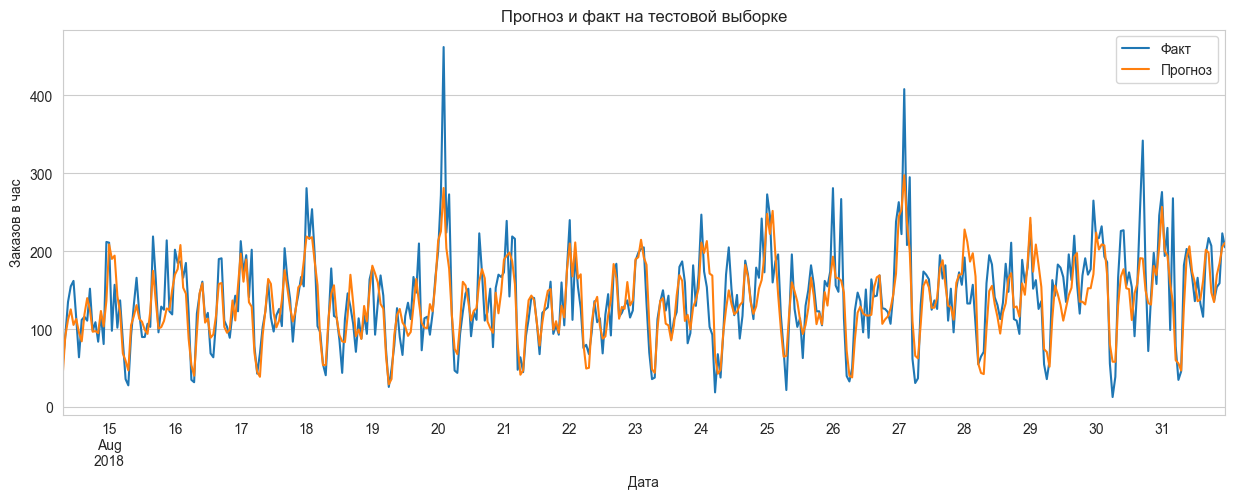

In [27]:
plt.figure(figsize=(15, 5))
target_test.plot(label='Факт')
pd.Series(test_pred, index=target_test.index).plot(label='Прогноз')
plt.title('Прогноз и факт на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Заказов в час')
plt.legend()
plt.show()

Финальный прогноз повторяет основную динамику тестового периода и реагирует на суточные пики. При оценке качества важно сравнивать его не только с порогом задачи, но и с сильным недельным бейзлайном `lag_168`.


## Общий вывод

- Исходные данные о заказах такси (март–август 2018 года, шаг 10 минут) были ресемплированы по одному часу — получили 4416 наблюдений без пропусков.
- Анализ показал восходящий тренд, устойчивую суточную сезонность и недельный паттерн. На общий график добавлены суточное и недельное скользящие средние, а недельная сезонность дополнительно проверена декомпозицией дневного ряда.
- В признаки добавлены `hour`, `dayofweek`, лаги до 168 часов и недельное `rolling_mean`. Признак `month` удалён, потому что данных всего за шесть месяцев, а тренд уже учитывается лагами и скользящим средним.
- Проверены наивные бейзлайны на тестовой выборке: `lag_1` дал **RMSE ≈ 58.82**, `lag_24` — **≈ 55.86**, `lag_168` — **≈ 39.29**. Самый сильный наивный прогноз — тот же час предыдущей недели.
- Для линейных моделей `hour` и `dayofweek` закодированы как категориальные через OHE внутри `Pipeline` и `ColumnTransformer`. В отдельном сравнении кодировок для Ridge лучше всего сработал `TargetEncoder` (**RMSE_test ≈ 33.75**), OHE был почти на том же уровне (**≈ 33.88**).
- По валидационной выборке лучшей стала `Lasso` с `alpha=0.1`. Перед тестом я обучил её на объединении train+valid, на тесте получил **RMSE ≈ 34.05**.
- Цель проекта достигнута: итоговая ошибка ниже порога **48** и лучше сильного недельного бейзлайна `lag_168` (**34.05 против 39.29**).


<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Дополнительные материалы </b>

Если решишь глубже погрузиться в тему временных рядов, думаю тебе стоит знать что подход, изученный в курсе далеко не единственный. Вот к чему возможно стоит обратиться:
 - Авторегрессионные модели семейства ARIMA. В качестве экскурса очень полезно следующее видео: https://www.youtube.com/watch?v=u433nrxdf5k&t=110s
 - Библиотека prophet от Facebook. По моим наблюдениям, качество решения этой моделью ниже, но она очень проста в применении. https://habr.com/ru/company/ods/blog/323730/
    
 - Урок по временным рядам из курса ML от ODS (https://habr.com/ru/company/ods/blog/327242/)
 - Лекция по прогнозированию временных рядов из курса Computer Science Center (https://www.youtube.com/watch?v=COBcXzKmOyk)   


</div>